In [27]:
!pip install statsforecast

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoETS, AutoARIMA

In [29]:
#Load the milk production dataset
url = 'https://raw.githubusercontent.com/plotly/datasets/master/monthly-milk-production-pounds.csv'
df = pd.read_csv(url, header=0, index_col=0, parse_dates=True)
df.columns = ['y']
df = df.reset_index().rename(columns={'Month': 'ds'}) #Corrected rename
df['unique_id'] = 'milk'  #Required format for statsforecast

#Reorder columns for Nixtla format
df = df[['unique_id', 'ds', 'y']]

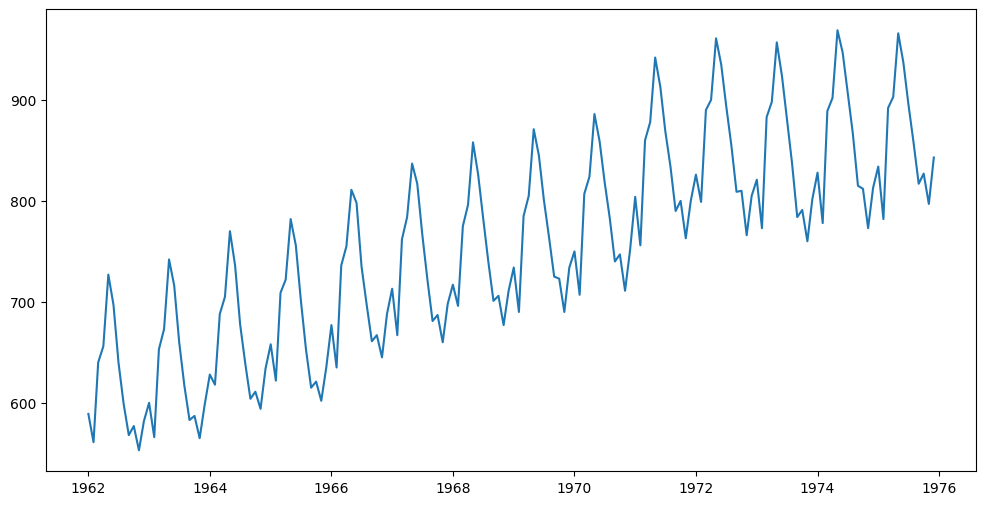

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['y'], label='Actual')

In [31]:
# Train-test split
train_df = df[df['ds'] < '1975-01-01']
test_df = df[df['ds'] >= '1975-01-01']

# Initialize the forecasting models
models = [
    SeasonalNaive(12),
    AutoETS(season_length=12),
    AutoARIMA(season_length=12)
]

# Fit models
sf = StatsForecast(models=models, freq='M', n_jobs=-1)
forecasts = sf.forecast(df=train_df, h=12)

/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:384: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/usr/local/lib/python3.12/dist-packages/utilsforecast/processing.py:440: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  freq = pd.tseries.frequencies.to_offset(freq)


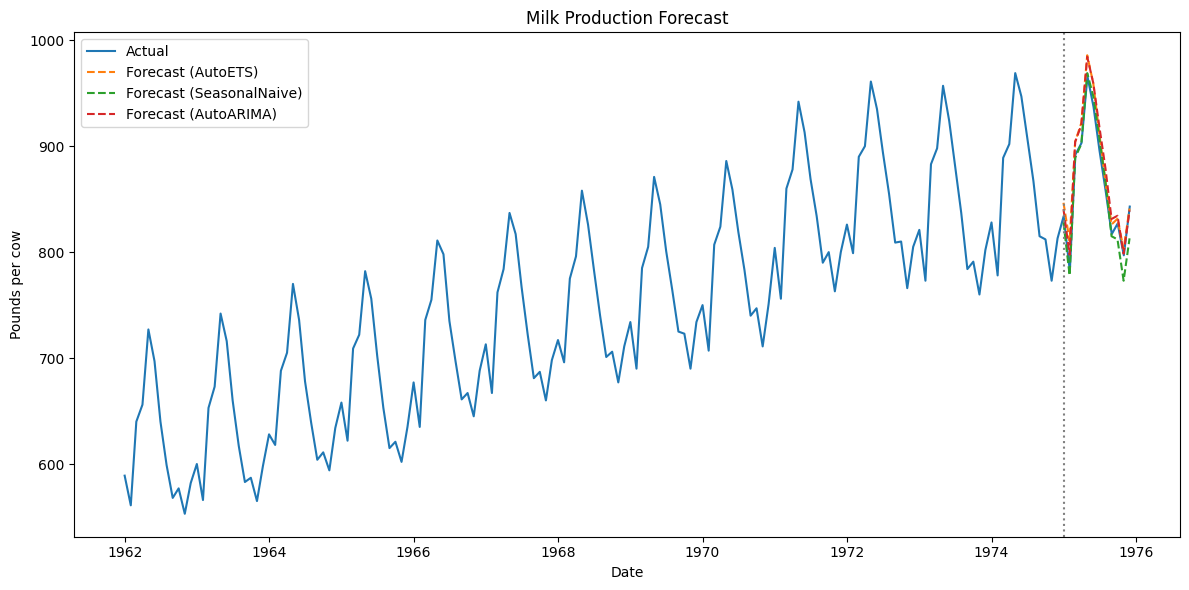

In [32]:
plt.figure(figsize=(12, 6))
plt.plot(df['ds'], df['y'], label='Actual')
plt.plot(forecasts['ds'], forecasts['AutoETS'], label='Forecast (AutoETS)', linestyle='--')
plt.plot(forecasts['ds'], forecasts['SeasonalNaive'], label='Forecast (SeasonalNaive)', linestyle='--')
plt.plot(forecasts['ds'], forecasts['AutoARIMA'], label='Forecast (AutoARIMA)', linestyle='--')
plt.axvline(pd.to_datetime('1975-01-01'), color='gray', linestyle=':')
plt.title('Milk Production Forecast')
plt.xlabel('Date')
plt.ylabel('Pounds per cow')
plt.legend()
plt.tight_layout()
plt.show()